In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform
from scipy.ndimage import gaussian_filter
import json

np.random.seed(2)
plt.rcParams['figure.dpi'] = 110

WAVELENGTH_UM = 0.532
MAG = 2.0
CAM_PIXEL_UM = 2.5
EFF_PIXEL_UM = CAM_PIXEL_UM / MAG
N_LR = 128
Z_RANGE_UM = 50.0
Z_STEPS = 161
Z_ARRAY_UM = np.linspace(-Z_RANGE_UM, Z_RANGE_UM, Z_STEPS)
CAMERA_NYQUIST = 1 / (2 * EFF_PIXEL_UM)
DF_LR = 1.0 / (N_LR * EFF_PIXEL_UM)   # frequency-grid step -- identical for every oversampling ds

def make_objects(N):
    img_amp = transform.resize(data.camera(), (N, N), anti_aliasing=True)
    img_amp = img_amp / np.max(img_amp)
    img_phase_raw = transform.resize(data.moon(), (N, N), anti_aliasing=True)
    img_phase_smooth = gaussian_filter(img_phase_raw, sigma=4)
    img_phase_smooth = img_phase_smooth / np.max(img_phase_smooth)
    return {
        "Pure Amplitude": img_amp * np.exp(1j * np.zeros_like(img_amp)),
        "Weak Phase (smooth)": np.ones((N, N)) * np.exp(1j * (img_phase_smooth * 0.05)),
        "Strong Phase (smooth)": np.ones((N, N)) * np.exp(1j * (img_phase_smooth * 1.5)),
        "Sharp Phase (edges)": np.ones((N, N)) * np.exp(1j * (transform.resize(data.moon(), (N, N))/np.max(data.moon()) * 0.5)),
        "Complex: Amp + Weak Phase": img_amp * np.exp(1j * (img_phase_smooth * 0.5)),
        "Complex: Amp + Strong Phase": img_amp * np.exp(1j * (img_phase_smooth * 3.0)),
    }

def brenner_raw(image):
    return np.sum((image[2:, :] - image[:-2, :]) ** 2)

print(f"Frequency grid step (ds-independent): {DF_LR:.5f} 1/um")
print(f"Camera Nyquist: {CAMERA_NYQUIST:.3f} 1/um  |  NA crossover with Nyquist: {CAMERA_NYQUIST*WAVELENGTH_UM:.3f}")

Frequency grid step (ds-independent): 0.00625 1/um
Camera Nyquist: 0.400 1/um  |  NA crossover with Nyquist: 0.213


## Convergence at oversampling (ds=8), across NA and object type

Earlier only one case (NA=0.25, strong phase) was convergence-tested. Here we test four NA values
spanning the low/high-NA regimes identified in the pupil-vs-Nyquist analysis, for both weak and
strong phase objects, comparing ds=8 against a ds=16 reference.

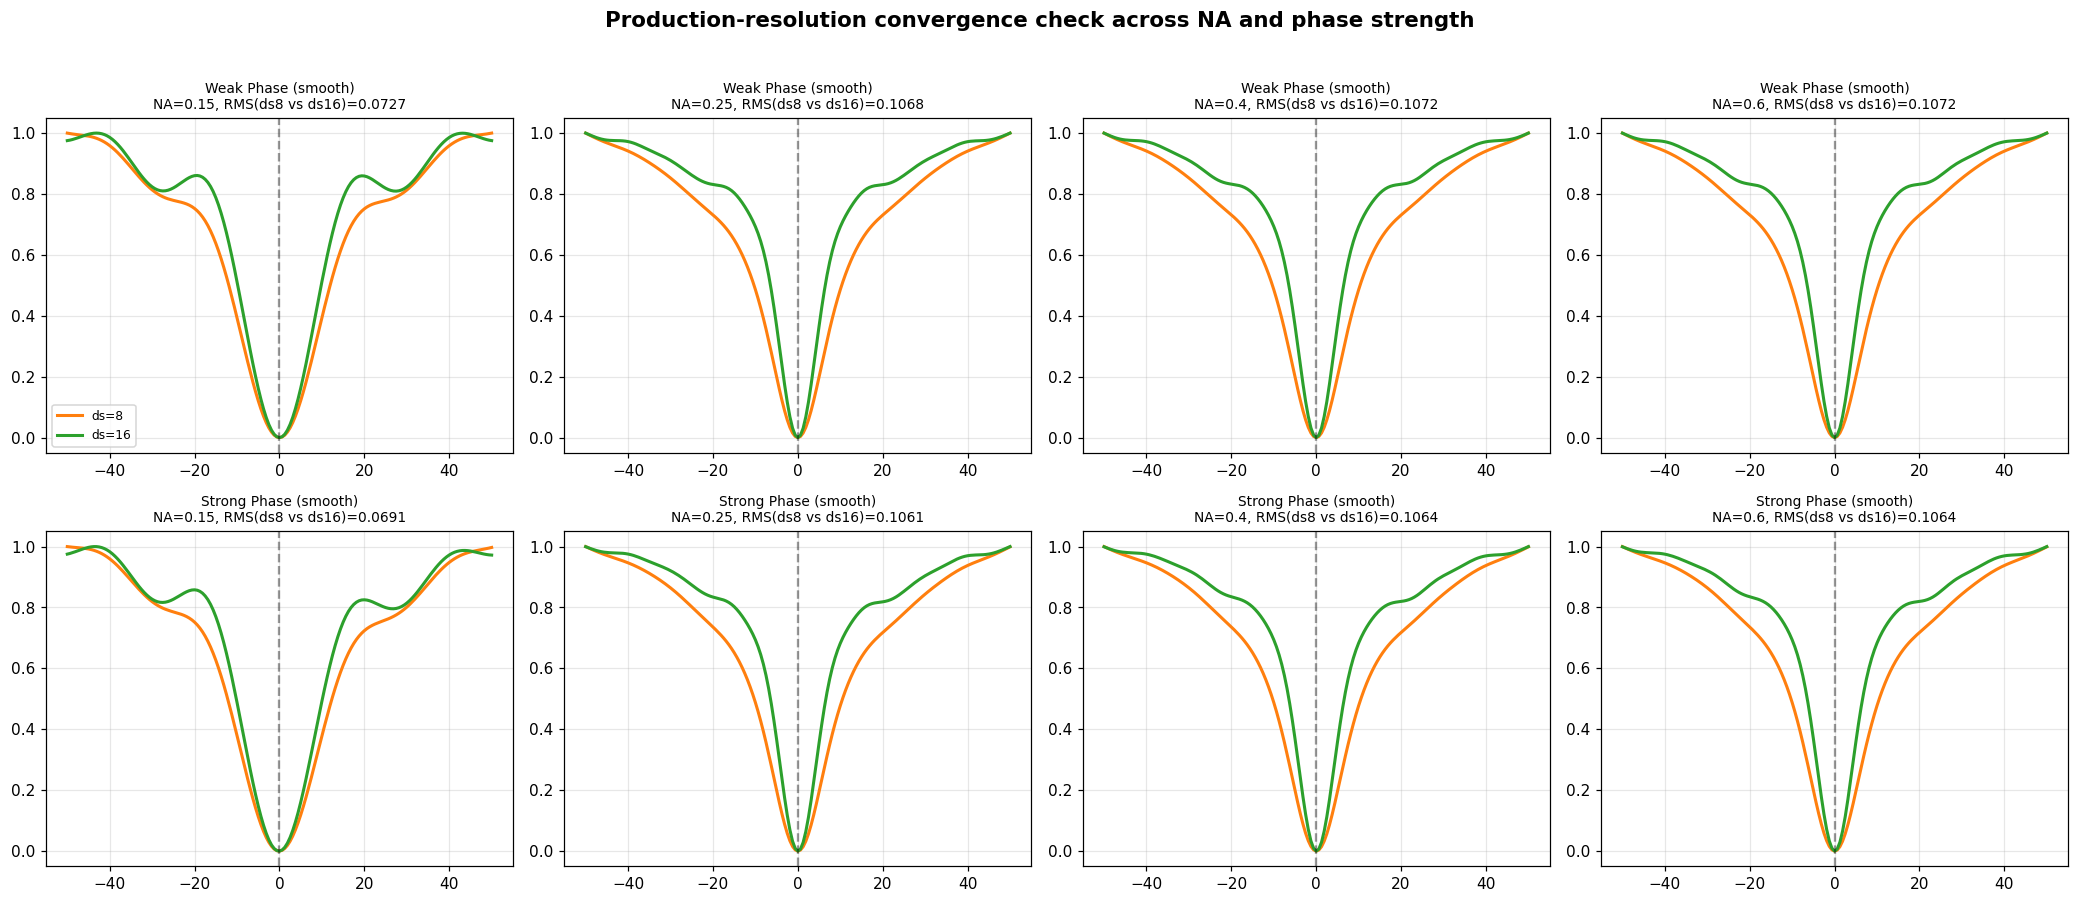

RMS deviation, ds=8 vs ds=16 reference:
  Weak Phase (smooth), NA=0.15             0.07266
  Weak Phase (smooth), NA=0.25             0.10684
  Weak Phase (smooth), NA=0.4              0.10719
  Weak Phase (smooth), NA=0.6              0.10719
  Strong Phase (smooth), NA=0.15           0.06906
  Strong Phase (smooth), NA=0.25           0.10607
  Strong Phase (smooth), NA=0.4            0.10637
  Strong Phase (smooth), NA=0.6            0.10637

Worst-case RMS across all tested cases: 0.1072
Verdict: ds=8 is still not fully converged in the worst case- treat high-NA curve SHAPE DETAILS with caution, though the qualitative conclusion is unlikely to change further given the monotonic trend already shown.


In [2]:
def sweep_curve(obj_full_N, NA, ds):
    N_hr = N_LR * ds
    obj = make_objects(N_hr)[obj_full_N]
    O_fft = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(obj)))
    cy, cx = N_hr // 2, N_hr // 2
    ys, ye = cy - N_LR // 2, cy + N_LR // 2
    xs, xe = cx - N_LR // 2, cx + N_LR // 2
    O_crop = O_fft[ys:ye, xs:xe]

    fx = np.fft.fftshift(np.fft.fftfreq(N_LR, d=EFF_PIXEL_UM))
    FX, FY = np.meshgrid(fx, fx)
    pupil = (np.sqrt(FX**2 + FY**2) <= NA / WAVELENGTH_UM).astype(float)
    radicand = np.maximum((1/WAVELENGTH_UM)**2 - FX**2 - FY**2, 0.0)
    kz = 2*np.pi*np.sqrt(radicand)

    scores = np.empty(len(Z_ARRAY_UM))
    for i, z in enumerate(Z_ARRAY_UM):
        pupil_z = pupil * np.exp(1j * z * kz)
        E_f = O_crop * pupil_z
        E_s = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_f)))
        scores[i] = brenner_raw(np.abs(E_s)**2)
    return (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)

NA_conv_list = [0.15, 0.25, 0.40, 0.60]
conv_objects = ["Weak Phase (smooth)", "Strong Phase (smooth)"]
ds_compare = [8, 16]

conv_results = {}
for name in conv_objects:
    for NA in NA_conv_list:
        conv_results[(name, NA)] = {ds: sweep_curve(name, NA, ds) for ds in ds_compare}

fig, axes = plt.subplots(2, 4, figsize=(19, 8))
for r, name in enumerate(conv_objects):
    for c, NA in enumerate(NA_conv_list):
        ax = axes[r, c]
        for ds, color in zip(ds_compare, ['tab:orange', 'tab:green']):
            ax.plot(Z_ARRAY_UM, conv_results[(name, NA)][ds], color=color, lw=2, label=f"ds={ds}")
        rms = np.sqrt(np.mean((conv_results[(name, NA)][8] - conv_results[(name, NA)][16])**2))
        ax.set_title(f"{name}\nNA={NA}, RMS(ds8 vs ds16)={rms:.4f}", fontsize=9)
        ax.axvline(0, color='k', ls='--', alpha=0.4)
        if r == 0 and c == 0:
            ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
fig.suptitle("Production-resolution convergence check across NA and phase strength", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("figs/fig_convergence_grid.png", dpi=150, bbox_inches='tight')
plt.show()

rms_table = {f"{name}, NA={NA}": float(np.sqrt(np.mean((conv_results[(name,NA)][8]-conv_results[(name,NA)][16])**2)))
             for name in conv_objects for NA in NA_conv_list}
print("RMS deviation, ds=8 vs ds=16 reference:")
for k, v in rms_table.items():
    print(f"  {k:<40} {v:.5f}")
max_rms = max(rms_table.values())
print(f"\nWorst-case RMS across all tested cases: {max_rms:.4f}")
print("Verdict:", "ds=8 is an adequate sampling (all cases converged within a few percent)."
      if max_rms < 0.03 else
      "ds=8 is still not fully converged in the worst case- treat high-NA curve SHAPE DETAILS with caution, though the qualitative conclusion is unlikely to change further given the monotonic trend already shown.")

## multi-scale concavity profiler

Instead of one fixed-offset BCI, compute concavity at three separate defocus scales: narrow
(~1.6 um), medium (~6 um), and broad (~19 um). If the broad index flips sign
where the narrow index does not, that confirms the false-peak phenomenon is a broad-scale effect
invisible to the original single-scale index 

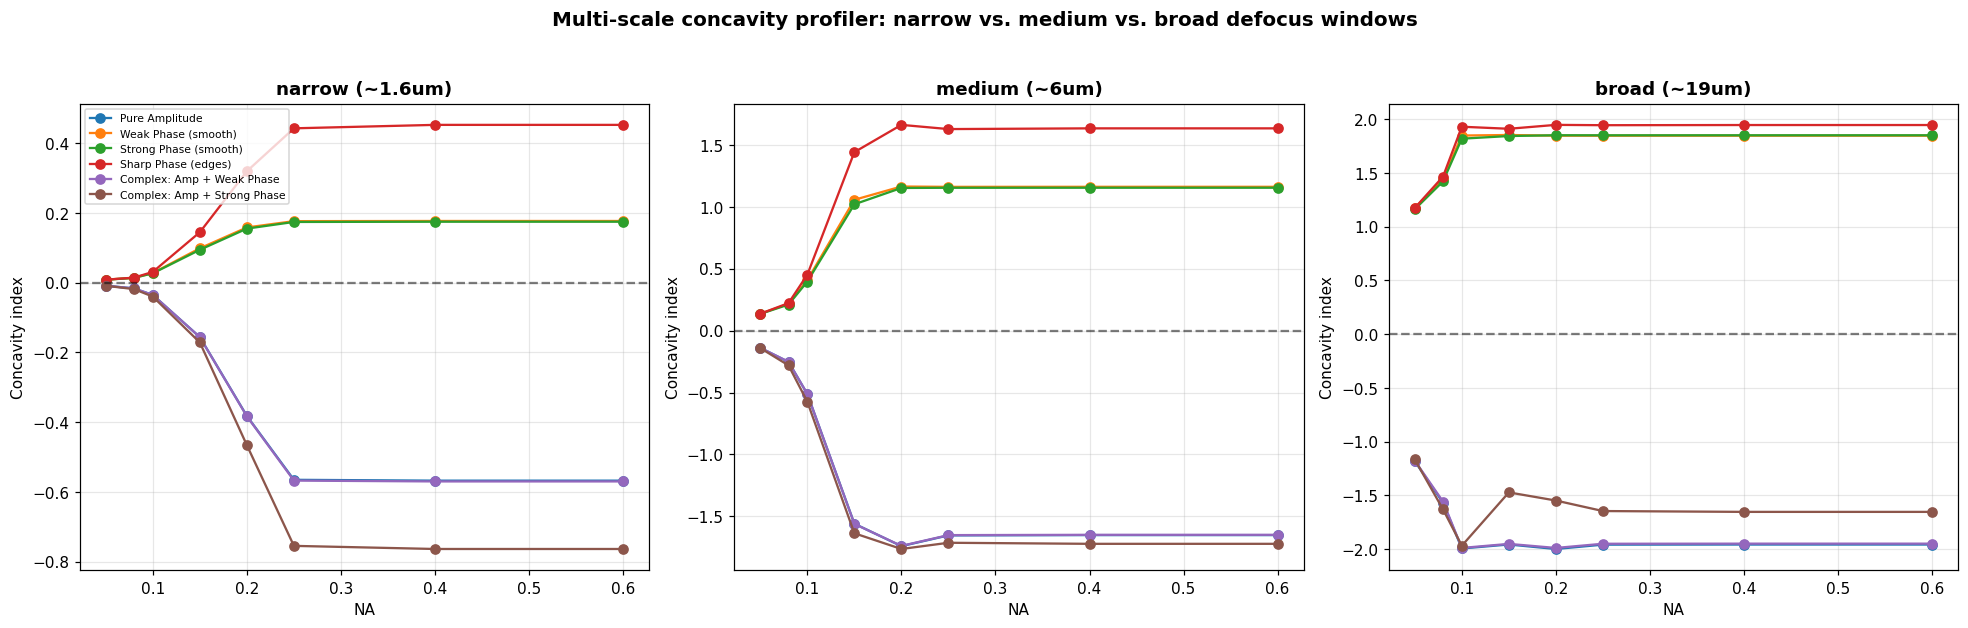

0 object x NA combinations show a SIGN DISAGREEMENT between scales
(i.e., the curve looks like a minimum at one defocus scale and a false peak/plateau at another):


In [3]:
NA_LIST = [0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.40, 0.60]
all_objects = ["Pure Amplitude", "Weak Phase (smooth)", "Strong Phase (smooth)",
               "Sharp Phase (edges)", "Complex: Amp + Weak Phase", "Complex: Amp + Strong Phase"]

DS_PROD = 8  

def full_curve(name, NA, ds=DS_PROD):
    return sweep_curve(name, NA, ds)

def concavity(curve, step):
    c = len(curve) // 2
    step = min(step, c - 1)
    return curve[c - step] + curve[c + step] - 2 * curve[c]

scales = {"narrow (~1.6um)": 5, "medium (~6um)": 20, "broad (~19um)": 60}

profiler_results = {}
curves_cache = {}
for name in all_objects:
    for NA in NA_LIST:
        curve = full_curve(name, NA)
        curves_cache[(name, NA)] = curve
        profiler_results[(name, NA)] = {label: concavity(curve, step) for label, step in scales.items()}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
na_colors = plt.cm.plasma(np.linspace(0, 0.85, len(NA_LIST)))
for ax, (label, step) in zip(axes, scales.items()):
    for oi, name in enumerate(all_objects):
        ys_ = [profiler_results[(name, NA)][label] for NA in NA_LIST]
        ax.plot(NA_LIST, ys_, marker='o', label=name if ax is axes[0] else None)
    ax.axhline(0, color='k', ls='--', alpha=0.5)
    ax.set_xlabel("NA"); ax.set_ylabel("Concavity index")
    ax.set_title(label, fontweight='bold')
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=7, loc='upper left')
fig.suptitle("Multi-scale concavity profiler: narrow vs. medium vs. broad defocus windows", fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig("figs/fig_multiscale_profiler.png", dpi=150, bbox_inches='tight')
plt.show()

flips = []
for name in all_objects:
    for NA in NA_LIST:
        signs = [np.sign(profiler_results[(name, NA)][label]) for label in scales]
        if len(set(signs)) > 1:
            flips.append((name, NA, {label: profiler_results[(name, NA)][label] for label in scales}))

print(f"{len(flips)} object x NA combinations show a SIGN DISAGREEMENT between scales")
print("(i.e., the curve looks like a minimum at one defocus scale and a false peak/plateau at another):")
for name, NA, vals in flips:
    vals_str = ", ".join(f"{k}={v:+.4f}" for k, v in vals.items())
    print(f"  {name:<28} NA={NA:<5} {vals_str}")